
# 🐧 Analisi Esplorativa del Dataset Palmer Penguins
Questo notebook analizza le caratteristiche morfologiche di tre specie di pinguini (Adelie, Chinstrap e Gentoo) osservate nell'arcipelago di Palmer. L'obiettivo è identificare pattern e differenze fisiche tra le specie tramite analisi statistica e visualizzazione dei dati.

In [1]:
import pandas as pd
import numpy as np
import statistics as st
import matplotlib.pyplot as plt
print('Pandas:',pd.__version__)

Pandas: 2.3.3


## 1. Caricamento e Ispezione dei Dati
In questa fase effettuiamo una prima analisi della struttura del dataset per verificarne il contenuto e l'integrità.

In [2]:
dfping = pd.read_csv(r"C:\Users\Luana\Documents\CORSI\CORSO DATA ANALYST\DATASETS\Progetto_pinguini\penguins - penguins.csv")

Uso metodi head() e tail() per una visualizzazione dei primi e degli ultimi record per un rapido controllo visivo dei dati.

In [3]:
dfping.head(4)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN


In [4]:
dfping.tail(4)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE
343,Gentoo,Biscoe,49.9,16.1,213.0,5400.0,MALE


Uso metodo describe() su tutto il DataFrame per un'analisi statistica descrittiva di tutte le variabili (numeriche e categoriche).

In [5]:
dfping.describe(include='all')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
count,344,344,342.000000,342.000000,342.000000,342.000000,334
unique,3,3,NaN,NaN,NaN,NaN,3
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,MALE
freq,152,168,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN


Uso metodi info() e shape() per una verifica delle dimensioni del dataframe e della tipologia dei dati per ogni colonna.

In [6]:
dfping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [7]:
dfping.shape

(344, 7)

Uso metodo isnull().sum() per una ricerca di eventuali valori mancanti (NaN) per pianificare la pulizia.

In [8]:
dfping.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

Uso metodo duplicated().sum() per un controllo della presenza di righe duplicate.

In [9]:
dfping.duplicated().sum()

np.int64(0)

### Descrizione del dataframe

Il Dataframe penguins è composto da 7 colonne a 344 righe. 

Le colonne: 
- species: è di tipo stringa ha solo 3 tipi di valori, contiene la specie di appartenenza del pinguino
- island: è il tipo di stringa ha solo 3 tipi di valori, contiene l'isola in cui vive il pinguino
- bill_length_mm: è di tipo numerico (float), indica la lunghezza del becco in millimetri.
- bill_depth_mm: è di tipo numerico (float), indica l'altezza del becco in millimetri.
- flipper_length_mm: è di tipo numerico (float), indica la lunghezza della pinna in millimetri.
- body_mass_g: è di tipo numerico (float/int), indica il peso del pinguino in grammi.
- sex: è di tipo stringa, indica il genere del pinguino (maschio o femmina).


# Data Cleaning
Durante l'analisi della colonna `sex`, è stata riscontrata la presenza di un valore anomalo registrato come `"."`. Trattandosi di un dato non conforme e non imputabile, si è proceduto a:
1. **Filtrare il dataset** per escludere la riga corrispondente.
2. **Creare una copia del dataframe** pulito per le analisi successive.
Questo passaggio garantisce che le aggregazioni per sesso e i futuri modelli statistici non vengano alterati da valori errati.


In [10]:
dfpingClean = dfping[dfping['sex']!='.'].copy()

### Rinominazione delle colonne (Localizzazione)

Per rendere l'analisi più intuitiva e i grafici più leggibili, abbiamo rinominato le variabili originali dall'inglese all'italiano. Questo passaggio facilita la comprensione dei dati e uniforma la nomenclatura per le fasi successive.

- species in specie
- island in isola 
- bill_length_mm in lunghezzaMM
- bill_depth_mm in altezzaBeccoMM
- flipper_length_mm in lunghezzaPinnaMM
- body_mass_g in pesoG
- sex in sesso

In [11]:
dfpingClean.rename(
    columns={
        "species" : "specie",
        "island" : "isola",
        "bill_length_mm" : "lunghezzaMM",
        "bill_depth_mm" : "altezzaBeccoMM",
        "flipper_length_mm" : "lunghezzaPinnaMM",
        "body_mass_g" : "pesoG",
        "sex" : "sesso"
    }, inplace=True
)

### Verifica finale del dataset pulito
Dopo le operazioni di pulizia e rinominazione, controlliamo le dimensioni finali del dataframe per confermare il numero di record pronti per l'analisi.


In [12]:
dfpingClean.shape

(343, 7)

### Controllo finale dei dati mancanti
Effettuiamo un ultimo controllo per identificare la presenza di valori nulli nelle colonne. Questo passaggio è cruciale prima di procedere alla visualizzazione grafica, poiché molti algoritmi e funzioni di plotting non gestiscono automaticamente i dati mancanti.


In [13]:
dfpingClean.isnull().sum()

specie               0
isola                0
lunghezzaMM          2
altezzaBeccoMM       2
lunghezzaPinnaMM     2
pesoG                2
sesso               10
dtype: int64

### Trattamento dei valori mancanti
Dall'ispezione precedente è emersa la presenza di record incompleti (NaN). Per garantire la massima precisione statistica e prevenire errori nelle visualizzazioni, abbiamo rimosso le righe contenenti dati mancanti.


In [14]:
dfpingClean.dropna(inplace=True)

### Validazione post-pulizia
Effettuiamo un controllo finale delle dimensioni del dataframe e dell'assenza di valori nulli. Questo ci permette di confermare che il processo di pulizia sia andato a buon fine e che il dataset sia ora integro e pronto per la visualizzazione.


In [15]:
dfpingClean.shape

(333, 7)

In [16]:
dfpingClean.isnull().sum()

specie              0
isola               0
lunghezzaMM         0
altezzaBeccoMM      0
lunghezzaPinnaMM    0
pesoG               0
sesso               0
dtype: int64

### Conversione delle unità di misura
Per facilitare l'interpretazione dei risultati, abbiamo convertito le grandezze fisiche in unità di misura più comuni:
* **Peso**: da grammi a chilogrammi (`pesoKG`).
* **Dimensioni**: da millimetri a centimetri (`lunghezzaCM`, `larghezzaCM`, `lpinnaCM`).

Infine, visualizziamo le prime righe per confermare il corretto calcolo delle nuove variabili.


In [17]:
dfpingClean.rename(
    columns={
        "body_mass_g" : "pesoG"
    }, inplace=True
)
# Creazione nuove variabili (Feature Engineering)
dfpingClean['pesoKG'] = dfpingClean['pesoG'] / 1000
dfpingClean['lunghezzaCM'] = dfpingClean['lunghezzaMM'] / 10
dfpingClean['altezzaBeccoCM'] = dfpingClean['altezzaBeccoMM'] / 10
dfpingClean['lpinnaCM'] = dfpingClean['lunghezzaPinnaMM'] / 10


In [18]:
dfpingClean.head()

,specie,isola,lunghezzaMM,altezzaBeccoMM,lunghezzaPinnaMM,pesoG,sesso,pesoKG,lunghezzaCM,altezzaBeccoCM,lpinnaCM
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE,3.75,3.91,1.87,18.1
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE,3.80,3.95,1.74,18.6
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE,3.25,4.03,1.80,19.5
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE,3.45,3.67,1.93,19.3
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE,3.65,3.93,2.06,19.0


## Data Manipulation
### Analisi Statistica Descrittiva Aggregata
Per comprendere meglio la distribuzione delle caratteristiche fisiche, abbiamo raggruppato i dati per **Isola**, **Specie** e **Sesso**. 

Per ogni gruppo abbiamo calcolato:
* **Peso (KG)**: numero di esemplari e peso medio.
* **Lunghezza Pinna (CM)**: media, valore minimo e valore massimo.

Questa tabella ci permette di individuare immediatamente i pattern dimensionali tra le diverse popolazioni di pinguini.

In [19]:
dfpingClean.groupby(['isola', 'specie' , 'sesso']).agg(
{
    'pesoKG' : ['count','mean'],
    'lpinnaCM' : ['mean' , 'min' , 'max']
}
).round(2)


pesoKG       lpinnaCM            
                            count  mean     mean   min   max
isola     specie    sesso                                   
Biscoe    Adelie    FEMALE     22  3.37    18.72  17.2  19.9
                    MALE       22  4.05    19.04  18.0  20.3
          Gentoo    FEMALE     58  4.68    21.27  20.3  22.2
                    MALE       61  5.48    22.15  20.8  23.1
Dream     Adelie    FEMALE     27  3.34    18.79  17.8  20.2
                    MALE       28  4.05    19.19  17.8  20.8
          Chinstrap FEMALE     34  3.53    19.17  17.8  20.2
                    MALE       34  3.94    19.99  18.7  21.2
Torgersen Adelie    FEMALE     24  3.40    18.83  17.6  19.6
                    MALE       23  4.03    19.49  18.1  21.0

### Distribuzione per Sesso
Effettuiamo un conteggio della variabile `sesso` per verificare quanto sia bilanciato il dataset tra esemplari maschi e femmine dopo le operazioni di pulizia.

In [20]:
dfpingClean['sesso'].value_counts()

sesso
MALE      168
FEMALE    165
Name: count, dtype: int64

### Distribuzione delle frequenze
Analizziamo la composizione del dataset attraverso il conteggio delle frequenze per le variabili categoriche principali. Questo ci permette di verificare:
*   **Bilanciamento di genere**: rapporto tra esemplari maschi e femmine.
*   **Rappresentanza delle specie**: numerosità per Adelie, Chinstrap e Gentoo.
*   **Distribuzione geografica**: concentrazione dei pinguini nelle tre isole (Biscoe, Dream, Torgersen).


In [21]:
display(dfpingClean['sesso'].value_counts())
display(dfpingClean['specie'].value_counts())
display(dfpingClean['isola'].value_counts())

sesso
MALE      168
FEMALE    165
Name: count, dtype: int64

specie
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

isola
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

## GRAFICI

### Distribuzione del peso dei pinguini

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

### Visualizzazione puntuale del peso (Grafico a linee)
In questa sezione cerchiamo di visualizzare la distribuzione del peso per ogni singolo individuo nel dataset. 
Il grafico utilizza dei marker per evidenziare il peso in KG e include etichette automatiche ogni 10 record per identificare specie e sesso degli esemplari.

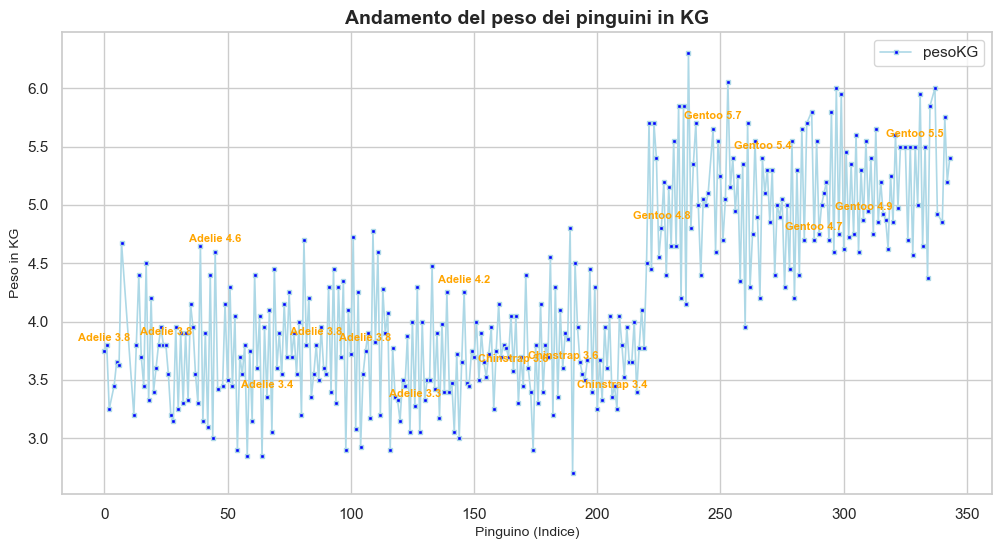

In [35]:
# Creiamo il grafico a linee (mantenendo kind='line')
graficoKGLine = dfpingClean.plot(
    kind='line',
    y='pesoKG',
    figsize=(12, 6),
    title='Andamento del peso dei pinguini in KG',
    grid=True,
    legend=True,
    color='lightblue',
    linewidth=1.2,
    marker='s',
    markersize=3,
    markerfacecolor='blue'
)

# Miglioriamo i titoli e gli assi
plt.title('Andamento del peso dei pinguini in KG', fontsize=14, fontweight='bold')
plt.xlabel('Pinguino (Indice)', fontsize=10)
plt.ylabel('Peso in KG', fontsize=10)

# Ciclo per le etichette (ne mettiamo una ogni 20 per non coprire tutto)
indice = 0
for i, row in dfpingClean.iterrows():
    if indice % 20 == 0:
        graficoKGLine.annotate(
            f'{row["specie"]} {row["pesoKG"]:.1f}', 
            (i, row['pesoKG']), # Qui usiamo 'i' che è il nome della riga (l'indice)
            xytext=(0, 7), 
            textcoords='offset points',
            ha='center',
            fontsize=8,
            color='orange',
            fontweight='bold'
        )
    indice += 1

plt.show()


### Visualizzazione dell'area di distribuzione del peso
In questa sezione utilizziamo un **Area Chart** per osservare l'andamento del peso attraverso i campioni del dataset. L'area colorata permette di percepire visivamente la "massa" dei dati, mentre la trasparenza aiuta a mantenere il grafico leggibile senza appesantire la visualizzazione.


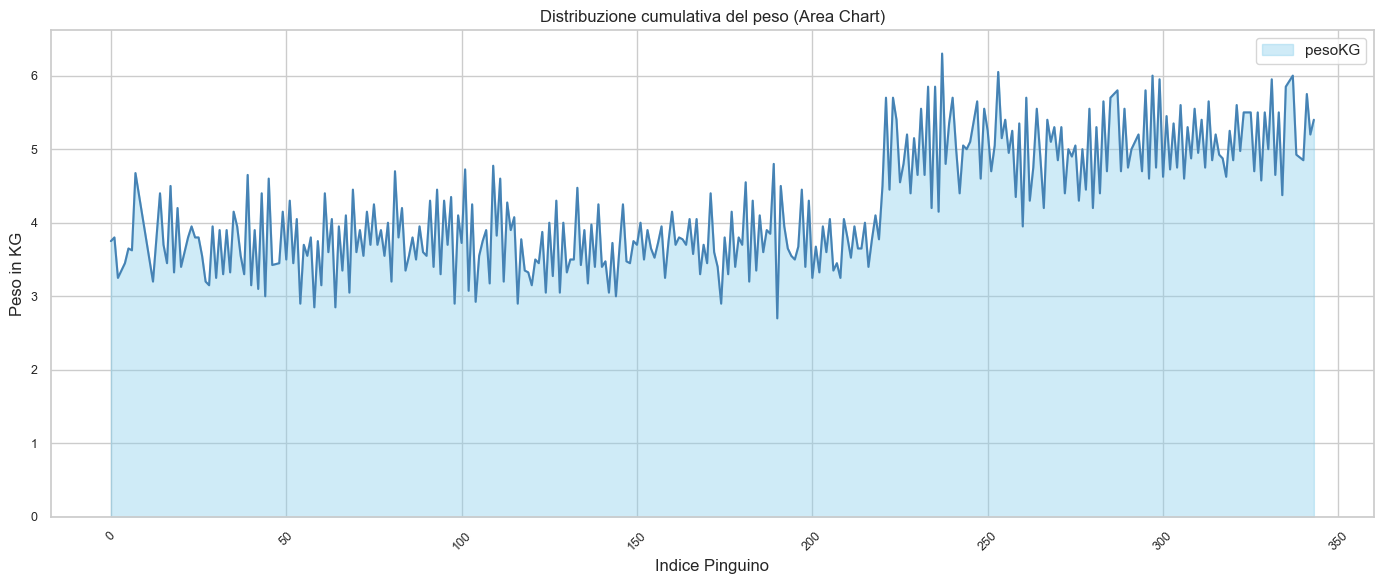

In [36]:
graficoKGArea = dfpingClean.plot(
    kind='area',
    y='pesoKG',
    figsize=(14,6),
    grid=True,
    legend=True,
    # ASSETTO ESTETICO
    color='skyblue',
    alpha=0.4, # Rende l'area semitrasparente e più professionale
    title='Distribuzione cumulativa del peso (Area Chart)',
    rot=45,    # 90 gradi è spesso difficile da leggere, 45 è un buon compromesso
    fontsize=9,
    xlabel='Indice Pinguino',
    ylabel='Peso in KG'
)

# Aggiungiamo una linea di contorno più marcata per definire meglio il bordo
plt.plot(dfpingClean.index, dfpingClean['pesoKG'], color="SteelBlue", lw=1.5)

plt.tight_layout()
plt.show()

### Visualizzazione a barre del peso
Utilizziamo un grafico a barre per confrontare il peso di ogni singolo individuo. Per migliorare la leggibilità rispetto alla versione originale, abbiamo rimosso i contrasti cromatici eccessivi e inserito una linea di riferimento che indica il **peso medio** del dataset, permettendo di individuare immediatamente gli esemplari sopra o sotto la media.


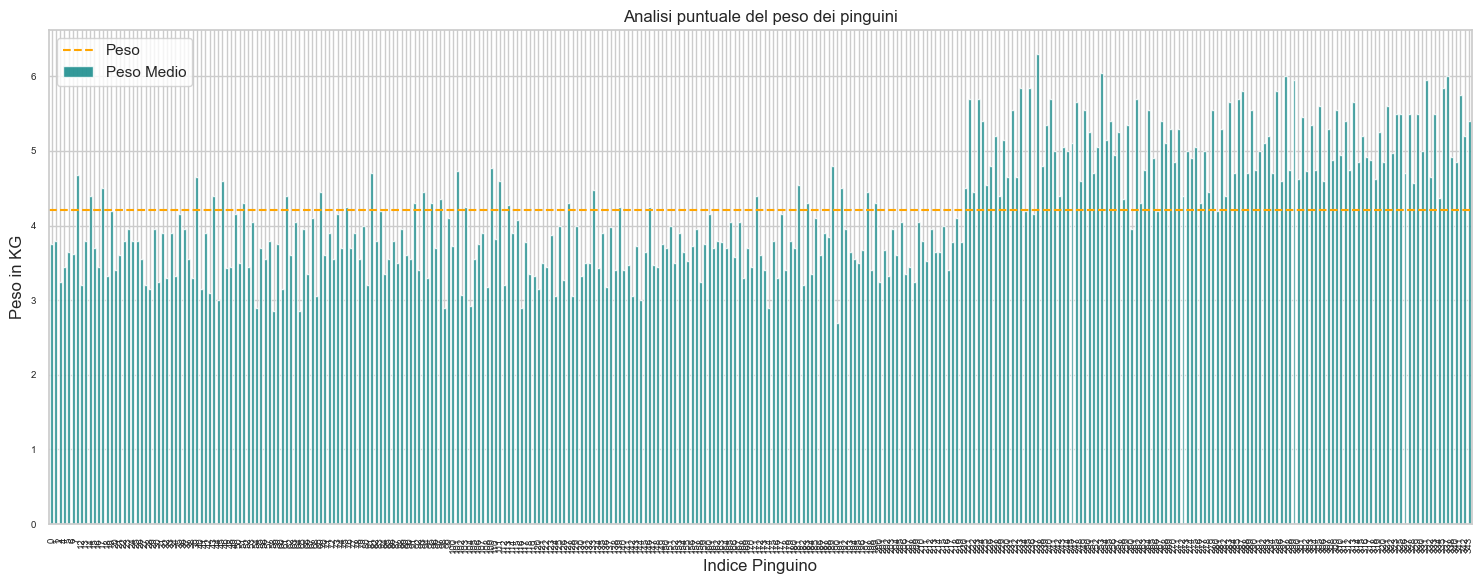

In [37]:
graficoKGBar = dfpingClean.plot(
    kind='bar',
    y='pesoKG',
    figsize=(15,6),
    title='Analisi puntuale del peso dei pinguini',
    grid=True,
    legend=False, # La legenda con una sola colonna è superflua
    color='teal',  # Un bel verde-azzurro professionale
    alpha=0.8,
    width=0.7,     # Barre un po' più larghe per riempire meglio lo spazio
    rot=90,
    fontsize=7,    # Font piccolo perché ci sono troppe etichette sotto
    xlabel='Indice Pinguino',
    ylabel='Peso in KG'
)

# Rimuoviamo i bordi rossi e aggiungiamo una linea media
plt.axhline(y=dfpingClean['pesoKG'].mean(), color='orange', linestyle='--', linewidth=1.5, label='Media')
plt.legend(['Peso', 'Peso Medio'])

plt.tight_layout()
plt.show()


### Confronto del peso medio per Specie e Sesso
In questa visualizzazione utilizziamo un grafico a barre orizzontali (**barh**) per confrontare il peso medio tra maschi e femmine delle diverse specie. Rispetto alla visualizzazione puntuale, questo approccio permette di identificare immediatamente il dimorfismo sessuale (i maschi sono mediamente più pesanti) e le differenze di massa tra le tre specie analizzate.


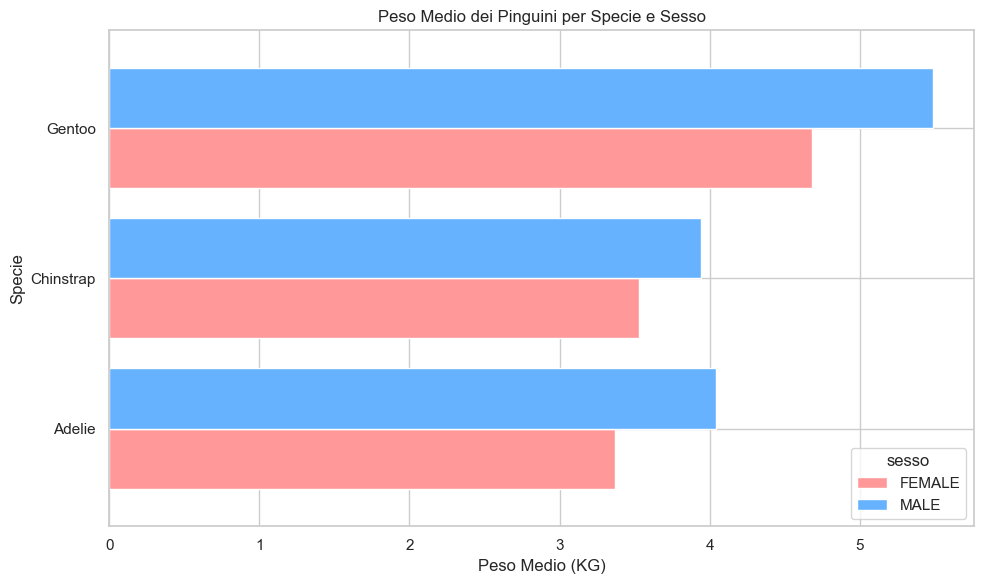

In [38]:
# Raggruppiamo per sesso e specie per avere un grafico compatto e sensato
analisi_media = dfpingClean.groupby(['specie', 'sesso'])['pesoKG'].mean().unstack()

graficoKG4 = analisi_media.plot(
    kind='barh',
    figsize=(10, 6), # Dimensione normale!
    title='Peso Medio dei Pinguini per Specie e Sesso',
    grid=True,
    color=['#FF9999', '#66B2FF'], # Rosa soft per femmine, azzurro per maschi (classico e pulito)
    edgecolor='white',
    linewidth=1,
    width=0.8
)

plt.xlabel('Peso Medio (KG)')
plt.ylabel('Specie')
plt.tight_layout()
plt.show()


### Analisi della distribuzione (Istogramma)
L'istogramma permette di osservare la frequenza delle diverse fasce di peso all'interno della popolazione. La scelta di una palette cromatica delicata e di un numero bilanciato di intervalli (**bins**) evidenzia la natura bimodale del dataset, mostrando chiaramente i due gruppi principali di peso che caratterizzano le diverse specie.


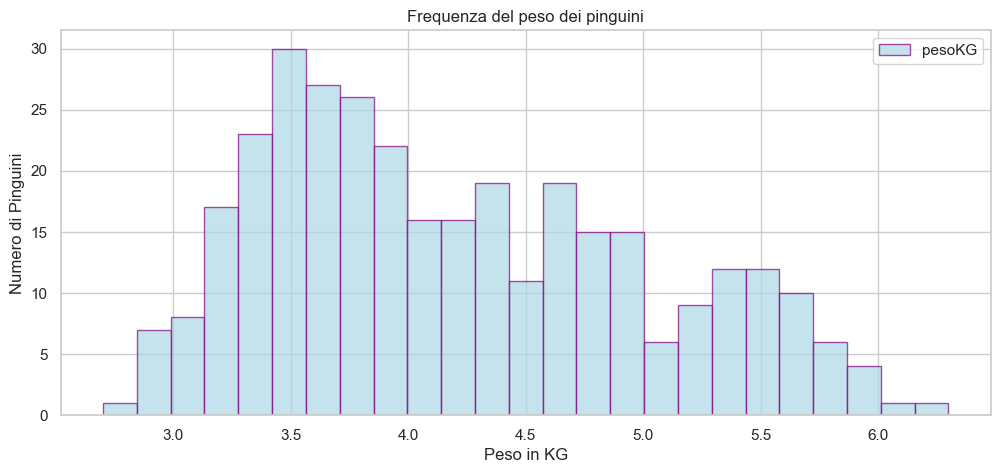

In [40]:
graficoKGHist = dfpingClean['pesoKG'].plot(
    kind='hist',
    figsize=(12,5), 
    title='Frequenza del peso dei pinguini',
    legend=True,
    grid=True,

    bins=25,        
    alpha=0.7,
    edgecolor='purple',
    color='lightblue',
    
    xlabel='Peso in KG', # Invertiti per logica: sull'asse X c'è il peso
    ylabel='Numero di Pinguini' # Sull'asse Y c'è il conteggio
)
plt.show()


### Analisi dei Quartili e Outlier (Boxplot)
Utilizziamo i boxplot per visualizzare la distribuzione statistica delle variabili numeriche. Questa rappresentazione permette di identificare:
* **Mediana** (linea viola) e **Media** (triangolo verde).
* **Variabilità** dei dati tramite l'ampiezza delle "scatole".
* **Valori anomali (Outlier)**, evidenziati dai punti rosa, che rappresentano esemplari con misure fuori dalla norma.
L'orientamento orizzontale facilita il confronto tra le diverse scale di misura.


<Axes: >

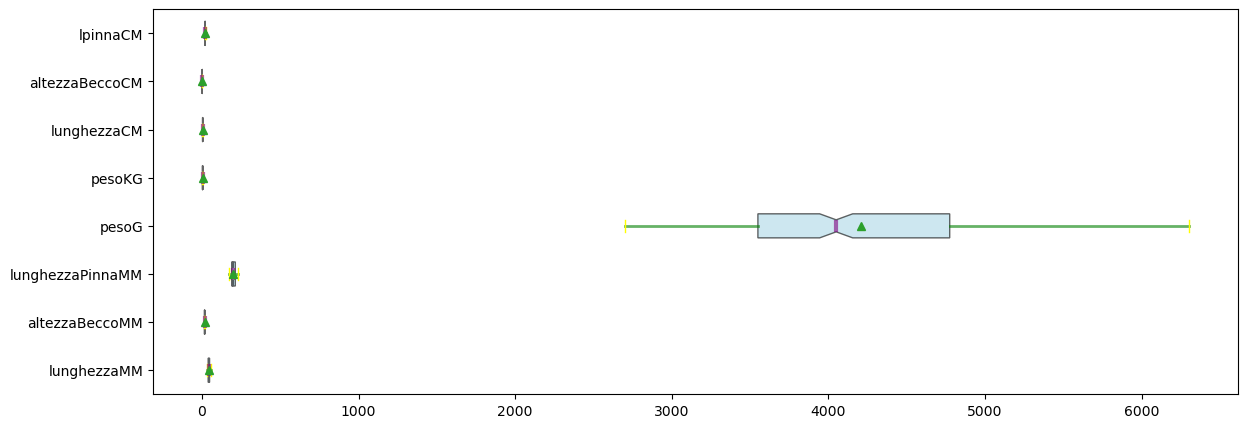

In [28]:
dfpingClean.plot(
    kind='box',
    vert=False,
    figsize=(14,5),
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', alpha=0.6),
    medianprops=dict(color='purple', alpha=0.6, linewidth=3),
    whiskerprops=dict(color='green', alpha=0.6, linewidth=2),
    capprops=dict(color='yellow'),
    flierprops=dict(marker='o', markersize=5, markerfacecolor='pink'),
    showmeans=True,
    notch=True,
)

### Analisi della Densità di Probabilità (KDE)
Il grafico KDE permette di visualizzare la funzione di densità di probabilità del peso, offrendo una visione continua della distribuzione dei dati. 
Abbiamo integrato l'analisi con:
* **Linea Viola (Dotted)**: Rappresenta la **Media** aritmetica del peso.
* **Linea Gialla (Dashed)**: Rappresenta la **Mediana**, ovvero il valore centrale della distribuzione.
Il confronto tra queste due misure centrali ci permette di valutare l'eventuale asimmetria (skewness) dei dati relativi alla massa corporea.


Media: 4.207057057057058
Mediana: 4.05


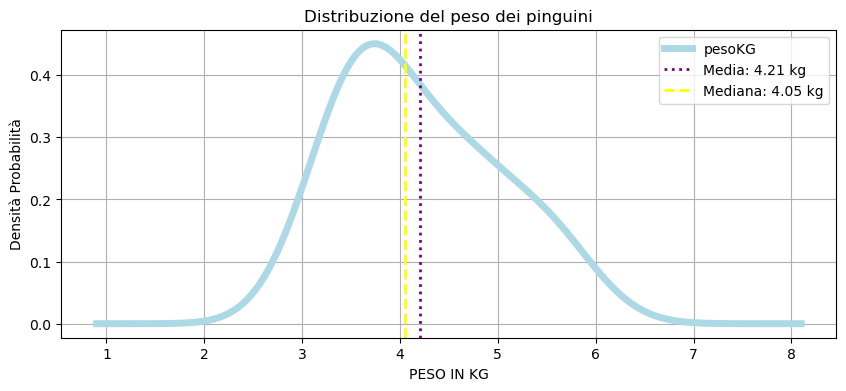

In [29]:
# 1. Crea il grafico KDE e assegnalo alla variabile
graficoKDE1 = dfpingClean['pesoKG'].plot(
    kind='kde',
    color='lightblue',
    figsize=(10,4),
    linewidth=5,
    title='Distribuzione del peso dei pinguini',
    legend=True,
    grid=True,
    bw_method=0.5
)

# 2. Configura le etichette degli assi (fuori dal plot)
graficoKDE1.set_xlabel('PESO IN KG')
graficoKDE1.set_ylabel('Densità Probabilità')

# 3. Calcola la Media e aggiungi la linea verticale
media = dfpingClean['pesoKG'].mean()
print(f"Media: {media}")
graficoKDE1.axvline(media, color='purple', linestyle='dotted', linewidth=2, label=f'Media: {media:.2f} kg')

# 4. Calcola la Mediana e aggiungi la linea verticale
mediana = dfpingClean['pesoKG'].median()
print(f"Mediana: {mediana}")
graficoKDE1.axvline(mediana, color='yellow', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana:.2f} kg')

# 5. Aggiorna la legenda per mostrare le nuove linee
graficoKDE1.legend()


### Analisi di Correlazione: Peso vs Lunghezza Becco
Attraverso lo **Scatter Plot** indaghiamo la relazione tra la massa corporea (`pesoKG`) e la dimensione del becco (`lunghezzaCM`). 
L'utilizzo di una scala cromatica per i punti permette di aggiungere una dimensione visiva ulteriore, facilitando l'identificazione dei gruppi di pinguini. La distribuzione dei punti suggerisce una correlazione positiva tra le due variabili, confermando che gli esemplari più pesanti tendono ad avere becchi più lunghi.


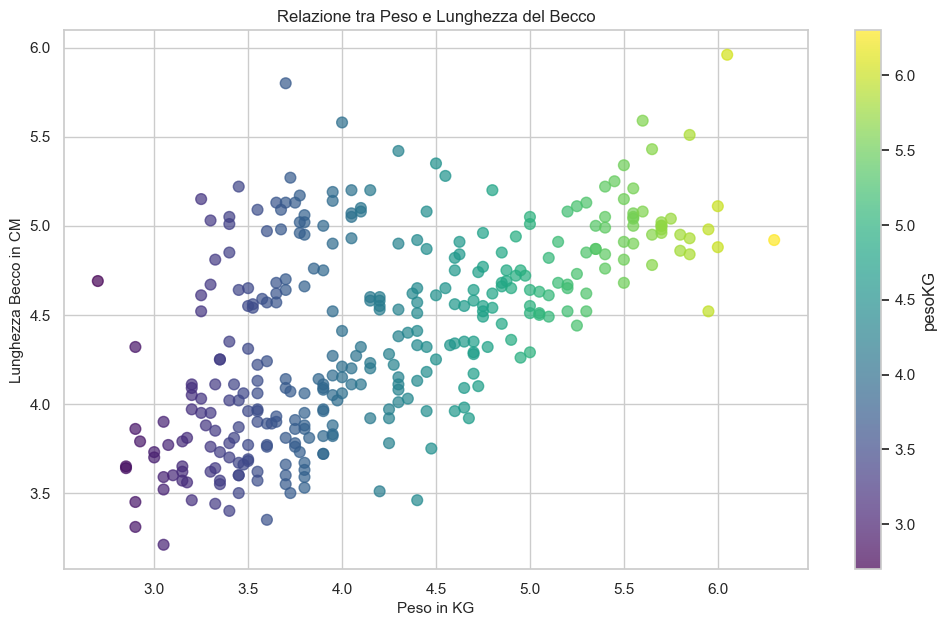

In [41]:
# Creazione dello Scatter Plot
graficoScatter = dfpingClean.plot(
    kind='scatter',
    x='pesoKG',
    y='lunghezzaCM',
    c='pesoKG',          # Il colore varia in base al peso
    figsize=(12, 7),
    title='Relazione tra Peso e Lunghezza del Becco',
    grid=True,
    cmap='viridis',      
    s=60,                
    alpha=0.7,           
    sharex=False        
)

plt.xlabel('Peso in KG', fontsize=11)
plt.ylabel('Lunghezza Becco in CM', fontsize=11)

# Mostriamo il grafico
plt.show()


### Analisi della densità (Hexbin Plot)
Per concludere l'analisi, utilizziamo un **Hexbin Plot**. Questo grafico a nido d'ape è particolarmente efficace per visualizzare la densità dei dati: l'intensità del colore degli esagoni indica le zone di maggiore concentrazione degli esemplari. Conferma visivamente il "cuore" della distribuzione del dataset, dove si concentra la maggior parte della popolazione in termini di peso e dimensioni del becco.


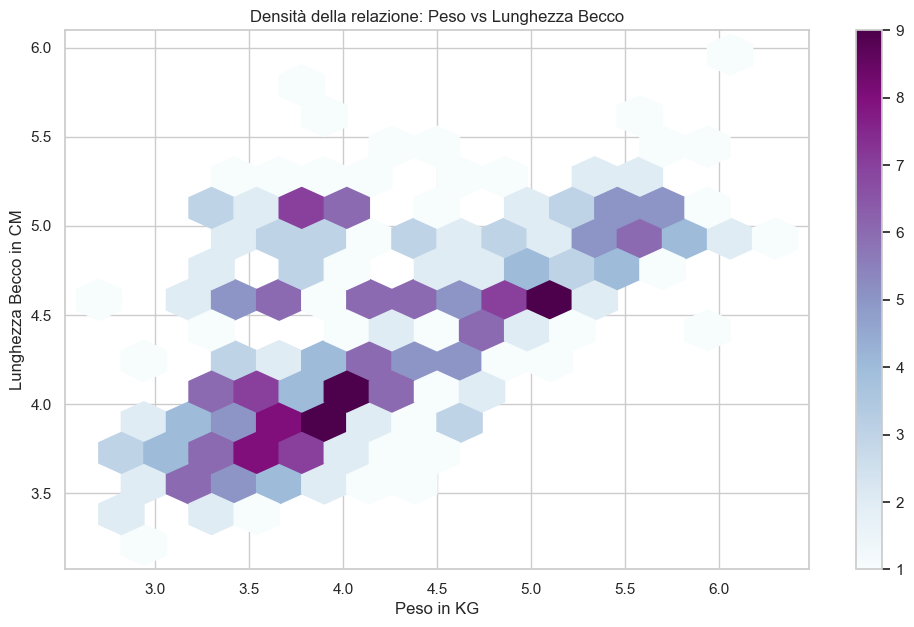

In [42]:
# Creazione del grafico Hexbin
graficoHex = dfpingClean.plot(
    kind='hexbin',
    x='pesoKG',
    y='lunghezzaCM',
    gridsize=15,        # Dimensione degli esagoni: più è alto, più sono piccoli
    figsize=(12, 7),
    title='Densità della relazione: Peso vs Lunghezza Becco',
    grid=True,
    mincnt=1,           # Non mostra gli esagoni vuoti
    cmap='BuPu',        # Una scala che va dal Blu al Purple, molto elegante
    sharex=False        # Per non far sparire l'etichetta X
)

plt.xlabel('Peso in KG')
plt.ylabel('Lunghezza Becco in CM')
plt.show()


# Conclusioni Finali

Al termine di questa analisi esplorativa sul dataset dei pinguini di Palmer, possiamo trarre le seguenti conclusioni:

### 1. Qualità e Pulizia dei Dati
Il dataset originale presentava alcune impurità (valori mancanti e dati non conformi nella colonna `sesso`) che sono state rimosse con successo. La normalizzazione delle unità di misura in **Chilogrammi** e **Centimetri** ha permesso una comprensione più immediata delle dimensioni fisiche degli esemplari.

### 2. Dimorfismo Sessuale e Differenze tra Specie
Attraverso l'analisi statistica e le visualizzazioni (Boxplot e KDE), è emerso chiaramente che:
*   Esiste un evidente **dimorfismo sessuale**: in tutte le specie analizzate, gli esemplari maschi tendono ad avere una massa corporea e dimensioni del becco superiori rispetto alle femmine.
*   I pinguini della specie **Gentoo** si distinguono nettamente per essere i più pesanti e grandi, con medie di peso che superano significativamente quelle delle specie Adelie e Chinstrap.

### 3. Correlazioni Morfologiche
Le analisi di correlazione (Scatter Plot e Hexbin) hanno confermato una relazione positiva tra il peso e le dimensioni del becco/pinne: all'aumentare della massa corporea si osserva un incremento proporzionale delle estremità.

### 4. Note Finali
Il lavoro di pulizia e visualizzazione ha trasformato un dataset grezzo in un report informativo e visivamente coerente, facilitando l'estrazione di pattern biologici significativi.
